In [1]:
import re
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import nltk
import pymorphy3
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess

from scipy.sparse import csr_matrix, vstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ndcg_score, precision_score, recall_score, f1_score, confusion_matrix

from catboost import CatBoostClassifier
from implicit.als import AlternatingLeastSquares
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

import optuna
from optuna.integration.mlflow import MLflowCallback

import mlflow
from mlflow.tracking import MlflowClient
from mlflow.utils.mlflow_tags import MLFLOW_PARENT_RUN_ID

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [2]:
random_state = 42
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

notebook_dir = Path.cwd()
repo_root = notebook_dir.parent
workspace_root = repo_root.parent
data_path = r"D:\Education\hr-ai-scout\total_df_10%.csv"
cache_dir = notebook_dir / "_ckpt7_cache"
cache_dir.mkdir(exist_ok=True)
artifact_dir = notebook_dir / "_ckpt7_artifacts"
artifact_dir.mkdir(exist_ok=True)

tracking_uri = "http://127.0.0.1:5000"
experiment_name = "hr-ai-scout-final"
registered_model_name = "hr-ai-scout-prd"
prd_alias = "PRD"

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_registry_uri(tracking_uri)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Где собирали данные

- Данные собраны с hh.ru, все подробности парсинга в Load_data
- Резюме и вакансии хранятся в ClickHouse, история запросов сервиса в SQLite (hr_scout_history.db, async SQLAlchemy)
- Бизнес-метрика NDCG, заказчику HR нужна возможность отбирать соискателей по порядку наиболее подходящих, NDCG оценивает насколько хорошо модель ранжирует всех соискателей по релевантности под конкретную вакансию
- Дополнительно считаются Precision, Recall, F1 как метрики бинарной классификации с порогом 0.5
- Ниже идут дословно скопированные из ML Experiments шаги препроцессинга, фича-инжиниринга TF-IDF, train test split и baseline LogisticRegression

</div>

In [3]:
df = pd.read_csv(str(data_path))
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_salary_from,vacancy_salary_to,vacancy_salary_currency,vacancy_salary_gross,...,resume_education,resume_courses,resume_salary,resume_age,resume_total_experience,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Казанский Авиационный Институт'],NaN,NaN,65.0,19 лет,228.0,Москва,Мужчина,Рассматривает предложения,1
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,"['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...","['ООО ""Открытый Учебный Центр СофтБаланс"", г. ...",NaN,43.0,17 лет 4 месяца,208.0,Москва,Мужчина,Рассматривает предложения,1
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Орский государственный педагогический инстит...,NaN,200 000 ₽ на руки,52.0,30 лет,360.0,Москва,Женщина,NaN,1
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Красноярский государственный университет'],NaN,500 000 ₽ на руки,56.0,29 лет 8 месяцев,356.0,Красноярск,Мужчина,Рассматривает предложения,1
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,300000.0,NaN,RUR,False,...,['Белоруский Гос. Университет Информатики и Ра...,"['SAP CIS, SAP XI', 'Школа Логистики МАДИ', 'S...",NaN,48.0,25 лет 1 месяц,301.0,Moscow,Male,NaN,1


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
В первую очередь уберем строки, где пропущены все ключевые значения в резюме:
</div>

In [4]:
t1 = df.shape[0]
df = df.dropna(subset= ["resume_education",
                        "resume_last_experience_description",
                        "resume_last_position",
                        "resume_last_company_experience_period",
                        "resume_total_experience",
                        "resume_experience_months",
                        "resume_location",
                        "resume_specialization",
                       ], how="all")
t2 = df.shape[0]
t1 - t2

84

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Удалим еще те строки, где случился технический сбой в парсинге, где у кандидата общий опыт есть, а последний опыт не указан (и наоборот):
</div>

In [5]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].notna()
        & df["resume_last_experience_description"].isna()
        & df["resume_last_position"].isna())]
t2 = df.shape[0]
t1 - t2

1543

In [6]:
t1 = df.shape[0]
df = df.loc[~(df["resume_total_experience"].isna()
        & df["resume_last_experience_description"].notna()
        & df["resume_last_position"].notna())]
t2 = df.shape[0]
t1 - t2

0

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Посмотрим на пропуски отдельно по категориальным и числовым признакам.
</div>

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [8]:
df[cat_cols] = df[cat_cols].fillna('NDT')

In [9]:
df.loc[df['resume_experience_months'].isna(), 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

In [10]:
df['resume_age'] = df['resume_age'].fillna(df['resume_age'].mean())
df['resume_experience_months'] = df['resume_experience_months'].fillna(0)

In [11]:
df = df.drop(['vacancy_salary_to', 'vacancy_salary_from',
              'vacancy_salary_currency', 'vacancy_salary_gross'], axis=1)

In [12]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Преобразуем сначала ожидаемые зарплаты
</div>

In [13]:
df['resume_salary_split'] = df['resume_salary'].apply(lambda x: x.split())

df['salary_int'] = df['resume_salary_split'].apply(
    lambda x: int(''.join(part for part in x if re.fullmatch(r'\d+', part)))
              if any(re.fullmatch(r'\d+', part) for part in x)
              else np.nan
)

currency_symbols = ['₽', '$', '€', '₴', '₸', '₼', '₾', 'Br', "so'm"]

rates_rub = {
    "₽": 1.0,
    "$": 80.85,
    "€": 94.14,
    "₴": 1.94,
    "₸": 0.150,
    "₼": 47.8,
    "₾": 33.5,
    "Br": 28.7,
    "so'm": 0.0068
}

df['currency_symbol'] = df['resume_salary_split'].apply(
    lambda x: next((sym for sym in x if sym in currency_symbols), np.nan)
)

df['salary_converted'] = (df['salary_int'] * df['currency_symbol'].map(rates_rub)).fillna(0)

df['resume_salary'] = df['salary_converted']

df = df.drop(['resume_salary_split', 'salary_int', 'currency_symbol', 'salary_converted'], axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим дополнительный столбец с опытом работы в последней компании в месяцах для удобства
</div>

In [14]:
def experience_to_months(experience_text):
    months = 0
    years_match = re.search(r'(\d+)\s*год', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    years_match = re.search(r'(\d+)\s*лет', experience_text)
    if years_match:
        months += int(years_match.group(1)) * 12

    months_match = re.search(r'(\d+)\s*месяц', experience_text)
    if months_match:
        months += int(months_match.group(1))

    return months if months > 0 else np.nan

In [15]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_period'].apply(experience_to_months)

In [16]:
df.loc[df['resume_last_company_experience_period'] == 'NDT', 'resume_last_experience_description'].unique()

array(['NDT'], dtype=object)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Так как в названии компании стоит NDT, можно столбец resume last company experience months заполнять нулевыми значениями

</div>

In [17]:
df['resume_last_company_experience_months'] = df['resume_last_company_experience_months'].fillna(0)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Ограничим выбросы по зарплате, потому что ровно одно значение по ожидаемой заработоной плате = 999,999,999 (смешно, но нет)

- Ограничим опыт общий и внутри одной компании до 720 месяцев (60 лет, ничего себе уже)

- Уберем возраст > 90, не ждем, что эти кандидаты находятся в поиске вакансии
</div>

In [18]:
df = df[~(df.resume_salary > 1e7)]
df.loc[df['resume_experience_months'] > 720, 'resume_experience_months'] = 720
df.loc[df['resume_last_company_experience_months'] > 720, 'resume_last_company_experience_months'] = 720
df = df[~(df.resume_age > 90)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Также уберем строки, где последний опыт кандидата больше, чем общий

- И где общий опыт кандидата +16 лет больше чем возраст (хоть так)

</div>

In [19]:
df = df[~(df.resume_experience_months < df.resume_last_company_experience_months)]
df = df[~(df.resume_age < (df.resume_experience_months // 12) + 16)]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Заменим текущий формат разброса полов в датасете на унифицированный

</div>

In [20]:
gender_map = {
    'Мужчина': 'Мужчина',
    'Male': 'Мужчина',
    'Женщина': 'Женщина',
    'Female': 'Женщина'
}

df['resume_gender'] = df['resume_gender'].apply(lambda x: gender_map[x] if x in gender_map else 'Неизвестно')

In [21]:
df.shape

(325543, 25)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">
Добавим признак матчинга локации вакансии и резюме

</div>

In [22]:
df['location_matching'] = df.apply(lambda row: 1 if row['vacancy_area'] == row['resume_location'] else 0, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Сделаем новый признак, посчитаем количество навыков кандидата, которые указаны в вакансии

</div>

In [23]:
def resume_skill_count_in_vacancy(row):
    count = 0
    skill_list = row['resume_skills'].replace('[', '').replace(']', '').replace("'", "").split(', ')
    for i in skill_list:
        if i in row['vacancy_description']:
            count += 1
    return count

df['resume_skill_count_in_vacancy'] = df.apply(resume_skill_count_in_vacancy, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Также посчитаем долю слов из последней должности в резюме, которые указаны в вакансии.

</div>

In [24]:
def last_position_in_vacancy(row):
    bow = []
    seps = [' ', '-', '_']
    for sep in seps:
        bow += row['resume_last_position'].split(sep=sep)
        bow = list(set(bow))
    
    c = 0
    for word in bow:
        if word in row['vacancy_description']:
            c +=1
    
    return c / len(bow)

In [25]:
df['last_position_in_vacancy'] = df.apply(last_position_in_vacancy, axis=1)

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Теперь закодируем описание вакансии и последнего опыта работы и сравним через косинусное расстояние.

</div>

In [26]:
def preprocess_data(df):
    df['vacancy_description'] = df['vacancy_description'].fillna('').astype(str)
    df['resume_last_experience_description'] = df['resume_last_experience_description'].fillna('').astype(str)
    return df

In [27]:
def save_results(df, output_file):
    df.to_csv(output_file, index=False, encoding='utf-8')

In [28]:
def calculate_cosine_similarity(embeddings1, embeddings2):
    similarities = []
    for i in tqdm(range(embeddings1.shape[0])):
        emb1_row = embeddings1[i]
        emb2_row = embeddings2[i]
        similarity = cosine_similarity(emb1_row, emb2_row)[0][0]
        similarities.append(similarity)
    return similarities

In [29]:
warnings.filterwarnings('ignore')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('taggers/averaged_perceptron_tagger_ru')
except LookupError:
    nltk.download('averaged_perceptron_tagger_ru')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

morph = pymorphy3.MorphAnalyzer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Puppalupa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [30]:
def lemmatize_russian(tokens):
    lemmas = []
    for token in tokens:
        parsed = morph.parse(token)[0]
        lemmas.append(parsed.normal_form)
    return lemmas

In [31]:
def tokenize_and_lemmatize(text):
    tokens = simple_preprocess(text, deacc=True, min_len=2)
    stop_words = set(stopwords.words('russian') + stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    lemmatized_tokens = lemmatize_russian(tokens)
    return lemmatized_tokens

In [32]:
def get_tfidf_embeddings(texts, vectorizer=None, fit=True):
    if fit:
        vectorizer = TfidfVectorizer(
            max_features=5000,
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2),
            tokenizer=tokenize_and_lemmatize,
            token_pattern=None,
            lowercase=False
        )
        embeddings = vectorizer.fit_transform(texts)
    else:
        embeddings = vectorizer.transform(texts)
    return embeddings, vectorizer

In [33]:
def get_tfidf_vacancy_embeddings(df, vectorizer=None):
    unique_vacancies = df[['vacancy_id', 'vacancy_description']].drop_duplicates()
    unique_embeddings, vectorizer = get_tfidf_embeddings(
        unique_vacancies['vacancy_description'].tolist(),
        vectorizer=vectorizer,
        fit=(vectorizer is None)
    )
    vacancy_embedding_dict = dict(zip(unique_vacancies['vacancy_id'], unique_embeddings))
    rows = []
    for vid in df['vacancy_id']:
        rows.append(vacancy_embedding_dict[vid])
    all_vacancy_embeddings = vstack(rows)
    return all_vacancy_embeddings, vectorizer

In [34]:
def process_similarity_scores_tfidf(df, vectorizer=None, fit=True):
    df = preprocess_data(df)
    experience_embeddings, tfidf_vectorizer = get_tfidf_embeddings(
        df['resume_last_experience_description'].tolist(),
        vectorizer=vectorizer, fit=fit,
    )
    vacancy_embeddings, _ = get_tfidf_vacancy_embeddings(df, vectorizer=tfidf_vectorizer)
    similarity_scores = calculate_cosine_similarity(vacancy_embeddings, experience_embeddings)
    df['similarity_score_tfidf'] = similarity_scores
    return df, tfidf_vectorizer

In [35]:
tfidf_cache_path = cache_dir / 'description_df_with_scores_tfidf.csv'
try:
    df_tfidf = pd.read_csv(tfidf_cache_path)
except FileNotFoundError:
    df_tfidf, _ = process_similarity_scores_tfidf(df.copy())
    save_results(df_tfidf, str(tfidf_cache_path))

In [36]:
df = df.merge(df_tfidf)

In [37]:
df.head()

,vacancy_id,vacancy_name,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,vacancy_description,resume_id,resume_title,resume_specialization,...,resume_experience_months,resume_location,resume_gender,resume_applicant_status,target,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf
0,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",6969174,ABAP-разработчик,"['Программист, разработчик']",...,228.0,Москва,Мужчина,Рассматривает предложения,1,76.0,1,3,0.666667,0.284047
1,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",9100077,"ABAP разработчик - SAP HCM, CRM, S/4HANA ERP(F...","['Программист, разработчик']",...,208.0,Москва,Мужчина,Рассматривает предложения,1,8.0,1,2,0.500000,0.308726
2,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",32644957,Разработчик ABAP,"['Программист, разработчик']",...,360.0,Москва,Женщина,NDT,1,136.0,1,1,0.000000,0.510093
3,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",27220466,ABAP-разработчик,"['Программист, разработчик']",...,356.0,Красноярск,Мужчина,Рассматривает предложения,1,135.0,0,2,0.333333,0.301062
4,126167948,Разработчик SAP ABAP,Москва,Более 6 лет,Полная занятость,Удаленная работа,"Привет!.redev — технологическая компания, созд...",7532708,ABAP разработчик. Senior ABAP Developer. SAP T...,"['Programmer, developer']",...,301.0,Moscow,Мужчина,NDT,1,0.0,0,2,0.600000,0.075429


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Добавим новые признаки в обучение и тестирование

</div>

In [38]:
features = [
    'vacancy_area',
    'vacancy_experience',
    'vacancy_employment',
    'vacancy_schedule',
    'resume_salary',
    'resume_age',
    'resume_experience_months',
    'resume_location',
    'resume_gender',
    'resume_applicant_status',
    'resume_last_company_experience_months',
    'location_matching',
    'resume_skill_count_in_vacancy',
    'last_position_in_vacancy',
    'similarity_score_tfidf'
]
df[features]

,vacancy_area,vacancy_experience,vacancy_employment,vacancy_schedule,resume_salary,resume_age,resume_experience_months,resume_location,resume_gender,resume_applicant_status,resume_last_company_experience_months,location_matching,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf
0,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,65.000000,228.0,Москва,Мужчина,Рассматривает предложения,76.0,1,3,0.666667,0.284047
1,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,43.000000,208.0,Москва,Мужчина,Рассматривает предложения,8.0,1,2,0.500000,0.308726
2,Москва,Более 6 лет,Полная занятость,Удаленная работа,200000.0,52.000000,360.0,Москва,Женщина,NDT,136.0,1,1,0.000000,0.510093
3,Москва,Более 6 лет,Полная занятость,Удаленная работа,500000.0,56.000000,356.0,Красноярск,Мужчина,Рассматривает предложения,135.0,0,2,0.333333,0.301062
4,Москва,Более 6 лет,Полная занятость,Удаленная работа,0.0,48.000000,301.0,Moscow,Мужчина,NDT,0.0,0,2,0.600000,0.075429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297188,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,60.000000,355.0,Moscow,Мужчина,Рассматривает предложения,0.0,0,0,0.000000,0.000000
297189,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,40.000000,213.0,Москва,Мужчина,Активно ищет работу,35.0,1,0,0.000000,0.000000
297190,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,80000.0,44.060813,121.0,Москва,Мужчина,NDT,44.0,1,0,0.200000,0.047398
297191,Москва,От 3 до 6 лет,Полная занятость,Удаленная работа,0.0,32.000000,117.0,Москва,Женщина,NDT,96.0,1,0,0.200000,0.029086


In [39]:
numeric_features = df[features].select_dtypes(include=np.number).columns
categorical_features = df[features].select_dtypes(exclude=np.number).columns

In [40]:
x = df[features].copy()
y = df['target'].copy()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

In [41]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((237754, 15), (59439, 15), (237754,), (59439,))

In [42]:
def calculate_metrics(df_test: pd.DataFrame):
    ndcg_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    vacancy_ids = df_test['vacancy_id'].unique()

    for vacancy_id in vacancy_ids:
        mask = df_test['vacancy_id'] == vacancy_id
        y_true = df_test.loc[mask, 'target'].values
        y_score = df_test.loc[mask, 'y_pred_proba'].values

        if len(y_true) <= 1:
            continue

        y_true_2d = y_true.reshape(1, -1)
        y_score_2d = y_score.reshape(1, -1)

        ndcg = ndcg_score(y_true_2d, y_score_2d)
        ndcg_scores.append(ndcg)

        y_pred_binary = (y_score >= 0.5).astype(int)
        precision_scores.append(precision_score(y_true, y_pred_binary, zero_division=0))
        recall_scores.append(recall_score(y_true, y_pred_binary, zero_division=0))
        f1_scores.append(f1_score(y_true, y_pred_binary, zero_division=0))

    if ndcg_scores:
        return (
            float(np.mean(ndcg_scores)),
            float(np.mean(precision_scores)),
            float(np.mean(recall_scores)),
            float(np.mean(f1_scores)),
        )
    return None, None, None, None

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Определим бейзлайн

- Обучим с подбором гиперпараметров LogisticRegression, как бейзлайн для сравнения с финальной моделью

</div>

In [43]:
tracking_server_host = "127.0.0.1"
tracking_server_port = 5000
study_db_name = f"sqlite:///{(cache_dir / 'local.study.db').as_posix()}"

mlflow.set_tracking_uri(f"http://{tracking_server_host}:{tracking_server_port}")
mlflow.set_registry_uri(f"http://{tracking_server_host}:{tracking_server_port}")

In [44]:
def objective(trial: optuna.Trial) -> float:
    params = {
        'model__C': trial.suggest_float('C', 1e-4, 1e4, log=True),
        'model__penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'model__solver': trial.suggest_categorical('solver', ['liblinear', 'saga'])
    }

    pipeline_lr_optuna = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('numeric_scaling', StandardScaler(), numeric_features),
            ('categorical_encoding', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
        ])),
        ('model', LogisticRegression(random_state=random_state, class_weight='balanced'))
    ])

    pipeline_lr_optuna.set_params(**params)

    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kfold.split(x_train, y_train):
        x_fold_train, x_fold_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline_lr_optuna.fit(x_fold_train, y_fold_train)
        y_pred_proba = pipeline_lr_optuna.predict_proba(x_fold_val)

        df_val = df.loc[x_fold_val.index].copy()
        df_val['y_pred_proba'] = y_pred_proba[:, 1]

        ndcg, _, _, _ = calculate_metrics(df_val)

        trial.set_user_attr('pipeline_params', params)

    return ndcg

In [45]:
baseline_experiment_name = "hr-ai-scout"

try:
    experiment_id = mlflow.get_experiment_by_name(baseline_experiment_name).experiment_id
except Exception:
    experiment_id = mlflow.create_experiment(baseline_experiment_name)

run_name_optune = 'LogisticRegression_optuna'

with mlflow.start_run(run_name=run_name_optune, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

🏃 View run LogisticRegression_optuna at: http://127.0.0.1:5000/#/experiments/1/runs/aff3c4882c7f4704a439ae28564afd7c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [46]:
study_name = "LogisticRegression_optuna"

mlflc = MLflowCallback(
    tracking_uri=f'http://{tracking_server_host}:{tracking_server_port}',
    metric_name="NDCG",
    create_experiment=False,
    mlflow_kwargs={'experiment_id': experiment_id, 'tags': {MLFLOW_PARENT_RUN_ID: run_id}}
)

In [47]:
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=random_state),
                            study_name=study_name,
                            storage=study_db_name,
                            load_if_exists=True)
study.optimize(objective,
               n_trials=20,
               callbacks=[mlflc]
              )
best_params_optuna = study.best_params
best_params_optuna

[I 2026-05-31 21:51:09,846] Using an existing study with name 'LogisticRegression_optuna' instead of creating a new one.
[I 2026-05-31 21:51:34,365] Trial 40 finished with value: 0.8110331940606927 and parameters: {'C': 3960.582695129287, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 40 at: http://127.0.0.1:5000/#/experiments/1/runs/3987b223bec1408a8fcd6b0393426a6c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:51:59,690] Trial 41 finished with value: 0.8118945173577293 and parameters: {'C': 4630.326303786845, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 41 at: http://127.0.0.1:5000/#/experiments/1/runs/5eb4a206f86644558f057cc817867302
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:52:24,296] Trial 42 finished with value: 0.8118945173577293 and parameters: {'C': 8251.234801633262, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 42 at: http://127.0.0.1:5000/#/experiments/1/runs/11af0ee884eb4d42944a616a0c1323fb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:52:49,102] Trial 43 finished with value: 0.8118945173577293 and parameters: {'C': 1041.7421328765963, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 43 at: http://127.0.0.1:5000/#/experiments/1/runs/6be4671cb2ca418fa48eb25f533abec6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:53:13,057] Trial 44 finished with value: 0.8118945173577293 and parameters: {'C': 419.9528494964961, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 44 at: http://127.0.0.1:5000/#/experiments/1/runs/8818845b9bc74a06af18aeea54eec51d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:53:36,957] Trial 45 finished with value: 0.8118945173577293 and parameters: {'C': 113.9557835890577, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 45 at: http://127.0.0.1:5000/#/experiments/1/runs/ada8c64ce15c431e842c7558af6b20ac
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:54:00,460] Trial 46 finished with value: 0.8110351491943616 and parameters: {'C': 2298.1775352683762, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 46 at: http://127.0.0.1:5000/#/experiments/1/runs/ec027361eee84ed4aa4631ad4ff4d96e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:54:25,749] Trial 47 finished with value: 0.8118945173577293 and parameters: {'C': 9911.531997166643, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 47 at: http://127.0.0.1:5000/#/experiments/1/runs/7e7e538e2cc34ea194df58156229d833
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:54:53,038] Trial 48 finished with value: 0.810955418584066 and parameters: {'C': 0.06040424271553322, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 48 at: http://127.0.0.1:5000/#/experiments/1/runs/1b52661de2234ea5a48c975af47add88
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:55:17,166] Trial 49 finished with value: 0.811902800874881 and parameters: {'C': 14.399794292744627, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 49 at: http://127.0.0.1:5000/#/experiments/1/runs/e49eed3727584de493c35f6f0f138061
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:55:41,532] Trial 50 finished with value: 0.8119001662685383 and parameters: {'C': 5.620910239339427, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 50 at: http://127.0.0.1:5000/#/experiments/1/runs/2feb12e3f39d49ebb21b345dff89f2ee
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:56:06,205] Trial 51 finished with value: 0.8118945173577293 and parameters: {'C': 1704.184656598213, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 51 at: http://127.0.0.1:5000/#/experiments/1/runs/a7e5aff1e87c4f1ab4e8a500be9686d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:56:31,091] Trial 52 finished with value: 0.8118945173577293 and parameters: {'C': 9255.650851723925, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 52 at: http://127.0.0.1:5000/#/experiments/1/runs/2f4358622d6a4e2daf517d904406927b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:56:55,711] Trial 53 finished with value: 0.8118945173577293 and parameters: {'C': 611.461862638348, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 53 at: http://127.0.0.1:5000/#/experiments/1/runs/399130b401a84bc699e5395bd8e17d82
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:57:20,476] Trial 54 finished with value: 0.8118945173577293 and parameters: {'C': 4339.233012919406, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 54 at: http://127.0.0.1:5000/#/experiments/1/runs/4eeccca52df8422192578769d6211727
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:57:44,936] Trial 55 finished with value: 0.8118878075150263 and parameters: {'C': 31.570818805673564, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 55 at: http://127.0.0.1:5000/#/experiments/1/runs/e18b8749c927494297749397666ae45e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:58:09,277] Trial 56 finished with value: 0.8118945173577293 and parameters: {'C': 1064.1967769216865, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 56 at: http://127.0.0.1:5000/#/experiments/1/runs/6e931a57b8684113b0caaf2670f78b8c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:58:30,230] Trial 57 finished with value: 0.8119619312819916 and parameters: {'C': 0.8731087406960655, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 57 at: http://127.0.0.1:5000/#/experiments/1/runs/59034c6f27c34866abacbfaf6e771bcb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:59:00,314] Trial 58 finished with value: 0.811201030245213 and parameters: {'C': 0.1685524799415459, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 58 at: http://127.0.0.1:5000/#/experiments/1/runs/da2d35f8ecc045f0978b0d029c94bdbd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


[I 2026-05-31 21:59:24,636] Trial 59 finished with value: 0.8118945173577293 and parameters: {'C': 345.0258702924712, 'penalty': 'l2', 'solver': 'saga'}. Best is trial 19 with value: 0.8247369211408225.


🏃 View run 59 at: http://127.0.0.1:5000/#/experiments/1/runs/d5d295680f844c94b55b9e9756936aaa
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


{'C': 0.5163300866510129, 'penalty': 'l2', 'solver': 'saga'}

In [48]:
study.best_trial.user_attrs['pipeline_params']

{'model__C': 0.5163300866510129,
 'model__penalty': 'l2',
 'model__solver': 'saga'}

In [49]:
pipeline_lr_best_optuna = Pipeline([
    ('preprocessing', ColumnTransformer([
        ('numeric_scaling', StandardScaler(), numeric_features),
        ('categorical_encoding', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])),
    ('model', LogisticRegression(random_state=random_state))
])

pipeline_lr_best_optuna.set_params(**study.best_trial.user_attrs['pipeline_params'])
pipeline_lr_best_optuna.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric_scaling', ...), ('categorical_encoding', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
y_pred_proba = pipeline_lr_best_optuna.predict_proba(x_test)

df_test = df.loc[x_test.index].copy()
df_test['y_pred_proba'] = y_pred_proba[:, 1]

In [51]:
ndcg_lr, precision_lr, recall_lr, f1_lr = calculate_metrics(df_test)

metrics_lr = {
    'NDCG': ndcg_lr,
    'Precision': precision_lr,
    'Recall': recall_lr,
    'F1': f1_lr
}

In [52]:
run_name = "best_optuna_lr"
registry_model_name = "best_optuna_lr"

mlflow.set_tracking_uri(f"http://{tracking_server_host}:{tracking_server_port}")
mlflow.set_registry_uri(f"http://{tracking_server_host}:{tracking_server_port}")
_exp = mlflow.get_experiment_by_name(baseline_experiment_name)
experiment_id = _exp.experiment_id if _exp is not None else mlflow.create_experiment(baseline_experiment_name)

signature = mlflow.models.infer_signature(x_test, y_test)
input_example = x_test[:10]

with mlflow.start_run(run_name=run_name, experiment_id=experiment_id) as run:
    run_id = run.info.run_id

    lr_info = mlflow.sklearn.log_model(
        sk_model=pipeline_lr_best_optuna,
        name='best_optuna_lr',
        registered_model_name=registry_model_name,
        signature=signature,
        input_example=input_example,
        await_registration_for=60,
    )
    mlflow.log_metrics(metrics_lr)
    mlflow.log_params(best_params_optuna)

2026/05/31 21:59:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'best_optuna_lr' already exists. Creating a new version of this model...
2026/05/31 21:59:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: best_optuna_lr, version 4


🏃 View run best_optuna_lr at: http://127.0.0.1:5000/#/experiments/1/runs/50102ae39fbc403a8f5e265ee22f08bf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '4' of model 'best_optuna_lr'.


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">


выбираем лучшую модель

- Финальная модель: CatBoost, ALS, TF-IDF, fine-tuned LaBSE, кросс-фичи

</div>

In [53]:
def encode_texts(texts, tokenizer, model, batch_size=64, prefix='', max_length=512):
    if prefix:
        texts = [prefix + t for t in texts]

    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="encoding"):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            out = model(**encoded)

        token_emb = out.last_hidden_state
        mask = encoded['attention_mask'].unsqueeze(-1).float()
        pooled = (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled = F.normalize(pooled, p=2, dim=1)
        all_embeddings.append(pooled.cpu().numpy())

    return np.vstack(all_embeddings)


def load_or_encode_embeddings(unique_ids, unique_texts, model_name, kind,
                              tokenizer, model, batch_size=64, prefix=''):
    safe_name = model_name.replace('/', '__').replace(':', '_')
    cache_file = cache_dir / f"emb_{safe_name}__{kind}.npz"

    cached_map = {}
    if cache_file.exists():
        cached = np.load(cache_file, allow_pickle=False)
        cached_ids = cached['ids'].astype(str)
        cached_emb = cached['emb']
        cached_map = {str(i): cached_emb[k] for k, i in enumerate(cached_ids)}

    missing_idx = [k for k, i in enumerate(unique_ids) if str(i) not in cached_map]

    if missing_idx:
        texts_to_enc = [unique_texts[k] for k in missing_idx]
        new_emb = encode_texts(texts_to_enc, tokenizer, model,
                               batch_size=batch_size, prefix=prefix)
        for j, k in enumerate(missing_idx):
            cached_map[str(unique_ids[k])] = new_emb[j]

        all_ids = list(cached_map.keys())
        all_emb = np.stack([cached_map[i] for i in all_ids]).astype(np.float32)
        np.savez(cache_file, ids=np.array(all_ids), emb=all_emb)

    return cached_map


def compute_bert_similarity(df, model_name, tokenizer, model,
                            batch_size=64, vacancy_prefix='', resume_prefix=''):
    df = df.copy()
    df['vacancy_description'] = df['vacancy_description'].fillna('').astype(str)
    df['resume_last_experience_description'] = (
        df['resume_last_experience_description'].fillna('').astype(str))

    unique_vac = df[['vacancy_id', 'vacancy_description']].drop_duplicates('vacancy_id')
    unique_res = df[['resume_id', 'resume_last_experience_description']].drop_duplicates('resume_id')

    vac_map = load_or_encode_embeddings(
        unique_vac['vacancy_id'].tolist(),
        unique_vac['vacancy_description'].tolist(),
        model_name, 'vac', tokenizer, model,
        batch_size=batch_size, prefix=vacancy_prefix,
    )
    res_map = load_or_encode_embeddings(
        unique_res['resume_id'].tolist(),
        unique_res['resume_last_experience_description'].tolist(),
        model_name, 'res', tokenizer, model,
        batch_size=batch_size, prefix=resume_prefix,
    )

    sims = [
        float(np.dot(vac_map[str(row.vacancy_id)], res_map[str(row.resume_id)]))
        if str(row.vacancy_id) in vac_map and str(row.resume_id) in res_map
        else 0.0
        for row in df.itertuples()
    ]
    return sims

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- BERT similarity
- Кодируем только уникальные тексты

</div>

In [54]:
baseline_model_name = 'cointegrated/LaBSE-en-ru'
baseline_sim_col    = 'sim_labse_en_ru'

_tokenizer = AutoTokenizer.from_pretrained(baseline_model_name)
_bert_model = AutoModel.from_pretrained(baseline_model_name).to(device).eval()

df[baseline_sim_col] = compute_bert_similarity(
    df, baseline_model_name, _tokenizer, _bert_model,
    batch_size=64,
)

del _tokenizer, _bert_model
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/LaBSE-en-ru
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- ALS факторизация

</div>

In [55]:
def create_interaction_matrix(df):
    unique_vacancies = df['vacancy_id'].unique().tolist()
    unique_resumes   = df['resume_id'].unique().tolist()
    id2vacancy = dict(enumerate(unique_vacancies))
    id2resume  = dict(enumerate(unique_resumes))
    vacancy2id = {v: k for k, v in id2vacancy.items()}
    resume2id  = {v: k for k, v in id2resume.items()}
    rows = [vacancy2id[v] for v in df['vacancy_id']]
    cols = [resume2id[r]  for r in df['resume_id']]
    matrix = csr_matrix((df['target'], (rows, cols)),
                        shape=(len(unique_vacancies), len(unique_resumes)),
                        dtype=np.float32)
    return matrix, id2vacancy, id2resume, vacancy2id, resume2id, unique_vacancies, unique_resumes


def get_factors(interactions_matrix):
    als = AlternatingLeastSquares(
        factors=64, regularization=0.1, iterations=30,
        random_state=random_state, num_threads=0)
    als.fit(interactions_matrix.T)
    return als.item_factors, als.user_factors


def get_als_score(vacancy_id, resume_id):
    if vacancy_id not in vacancy2id or resume_id not in resume2id:
        return 0
    return float(np.dot(vacancy_factors[vacancy2id[vacancy_id]],
                         resume_factors[resume2id[resume_id]]))

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Воспроизводимость через фиксацию параметров обучения и разбиения данных

- ALS обучается на части трейна чтобы избежать дата лика, затем переобучается на полном трейне для предикта

</div>

In [56]:
base_features = [
    'vacancy_area',
    'vacancy_experience',
    'vacancy_employment',
    'vacancy_schedule',
    'resume_salary',
    'resume_age',
    'resume_experience_months',
    'resume_location',
    'resume_gender',
    'resume_applicant_status',
    'resume_last_company_experience_months',
    'location_matching',
    'resume_skill_count_in_vacancy',
    'last_position_in_vacancy',
    'similarity_score_tfidf',
]

categorical_features = df[base_features].select_dtypes(exclude=np.number).columns.tolist()
numeric_features     = df[base_features].select_dtypes(include=np.number).columns.tolist()

x_base = df[base_features].copy()
y      = df['target'].copy()

x_train, x_test, y_train, y_test = train_test_split(
    x_base, y, test_size=0.2, random_state=random_state, stratify=y)

In [57]:
x_train_als, _, y_train_als, _ = train_test_split(
    x_train, y_train, test_size=0.3, random_state=random_state, stratify=y_train)

train_als_interactions = df.loc[x_train_als.index, ['vacancy_id', 'resume_id', 'target']]
interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, \
    unique_vacancies, unique_resumes = create_interaction_matrix(train_als_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

x_train['als_score'] = df.loc[x_train.index].apply(
    lambda row: get_als_score(row['vacancy_id'], row['resume_id']), axis=1)

train_interactions = df.loc[x_train.index, ['vacancy_id', 'resume_id', 'target']]
interactions_matrix, id2vacancy, id2resume, vacancy2id, resume2id, \
    unique_vacancies, unique_resumes = create_interaction_matrix(train_interactions)
vacancy_factors, resume_factors = get_factors(interactions_matrix)

x_test['als_score'] = df.loc[x_test.index].apply(
    lambda row: get_als_score(row['vacancy_id'], row['resume_id']), axis=1)

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Fine-tuning LaBSE en ru на обучающих парах vacancy description, resume last experience description и target
- Используем только индексы X train, чтобы не допустить утечки данных из тест сета
- При наличии готового чекпойнта в ckpt7 cache LaBSE hr finetuned обучение пропускается, продолжение с того же места

</div>

In [58]:
finetune_base_model = 'cointegrated/LaBSE-en-ru'
finetune_save_path  = cache_dir / 'LaBSE-hr-finetuned'
finetune_model_key  = 'LaBSE-hr-finetuned'
ft_sim_col          = 'sim_labse_hr_finetuned'

finetune_save_path.mkdir(parents=True, exist_ok=True)

In [59]:
ft_df = df.loc[x_train.index,
               ['vacancy_description', 'resume_last_experience_description', 'target']].copy()
ft_df['vacancy_description'] = ft_df['vacancy_description'].fillna('').astype(str)
ft_df['resume_last_experience_description'] = (
    ft_df['resume_last_experience_description'].fillna('').astype(str))

n_max = 15_000
pos = ft_df[ft_df['target'] == 1].sample(
    min(n_max, int(ft_df['target'].sum())), random_state=random_state)
neg = ft_df[ft_df['target'] == 0].sample(
    min(n_max, int((ft_df['target'] == 0).sum())), random_state=random_state)
ft_pairs = pd.concat([pos, neg]).sample(frac=1, random_state=random_state).reset_index(drop=True)

In [60]:
n_epochs   = 3
batch_size = 16
lr         = 2e-5
max_len    = 256
state_file = finetune_save_path / 'training_state.json'

def mean_pool(token_emb, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (token_emb * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

checkpoint_exists = finetune_save_path.is_dir() and (finetune_save_path / 'config.json').is_file()

if checkpoint_exists:
    ft_tokenizer    = AutoTokenizer.from_pretrained(str(finetune_save_path))
    ft_model_train  = AutoModel.from_pretrained(str(finetune_save_path)).to(device)
    state           = json.loads(state_file.read_text()) if state_file.is_file() else {}
    epochs_done     = state.get('epochs_completed', 0)
else:
    ft_tokenizer    = AutoTokenizer.from_pretrained(finetune_base_model)
    ft_model_train  = AutoModel.from_pretrained(finetune_base_model).to(device)
    epochs_done     = 0

ft_model_train.train()

optimizer = AdamW(ft_model_train.parameters(), lr=lr)
n_steps   = (len(ft_pairs) // batch_size) * n_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.05 * n_steps)),
    num_training_steps=n_steps,
)

for epoch in range(n_epochs):
    global_epoch = epochs_done + epoch + 1
    shuffled = ft_pairs.sample(frac=1, random_state=global_epoch).reset_index(drop=True)
    total_loss, n_batches = 0.0, 0

    for i in tqdm(range(0, len(shuffled), batch_size),
                  desc=f"Epoch {global_epoch} (session {epoch+1}/{n_epochs})"):
        batch  = shuffled.iloc[i : i + batch_size]
        texts1 = batch['vacancy_description'].tolist()
        texts2 = batch['resume_last_experience_description'].tolist()
        labels = torch.tensor(
            batch['target'].values * 2 - 1, dtype=torch.float).to(device)

        enc1 = ft_tokenizer(texts1, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)
        enc2 = ft_tokenizer(texts2, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)

        optimizer.zero_grad()
        emb1 = F.normalize(mean_pool(ft_model_train(**enc1).last_hidden_state,
                                     enc1['attention_mask']), p=2, dim=1)
        emb2 = F.normalize(mean_pool(ft_model_train(**enc2).last_hidden_state,
                                     enc2['attention_mask']), p=2, dim=1)

        loss = F.cosine_embedding_loss(emb1, emb2, labels, margin=0.5)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model_train.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item(); n_batches += 1

    avg_loss = total_loss / n_batches

    ft_model_train.eval()
    ft_model_train.save_pretrained(str(finetune_save_path))
    ft_tokenizer.save_pretrained(str(finetune_save_path))
    state_file.write_text(json.dumps(
        {'epochs_completed': global_epoch, 'last_avg_loss': avg_loss}, indent=2))
    ft_model_train.train()

ft_model_train.eval()

del optimizer, scheduler, ft_model_train
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 7 (session 1/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 8 (session 2/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 9 (session 3/3):   0%|          | 0/1875 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Similarity по fine-tuned LaBSE
- Кодируем уникальные тексты с помощью дообученной модели

</div>

In [61]:
_tokenizer_ft = AutoTokenizer.from_pretrained(str(finetune_save_path))
_model_ft     = AutoModel.from_pretrained(str(finetune_save_path)).to(device).eval()

df[ft_sim_col] = compute_bert_similarity(
    df, finetune_model_key, _tokenizer_ft, _model_ft,
    batch_size=64,
)

del _tokenizer_ft, _model_ft
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Обучаем выбранную модель с MLflow, логирование гиперпараметров и метрик


</div>

In [62]:
final_features = base_features + ['als_score', ft_sim_col]

x_tr = x_train[base_features + ['als_score']].copy()
x_tr[ft_sim_col] = df.loc[x_train.index, ft_sim_col].values

x_te = x_test[base_features + ['als_score']].copy()
x_te[ft_sim_col] = df.loc[x_test.index, ft_sim_col].values

In [63]:
def objective_catboost(trial: optuna.Trial) -> float:
    params = {
        'model__iterations':     trial.suggest_int('iterations', 100, 1000, step=50),
        'model__depth':          trial.suggest_int('depth', 3, 10),
        'model__learning_rate':  trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'model__l2_leaf_reg':    trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
    }

    pipeline_cb = Pipeline([
        ('preprocessing', ColumnTransformer([
            ('categorical_encoding',
             OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
             categorical_features),
        ], remainder='passthrough')),
        ('model', CatBoostClassifier(
            random_state=random_state, verbose=0,
            auto_class_weights='Balanced',
        )),
    ])
    pipeline_cb.set_params(**params)

    kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    ndcgs = []
    for tr_idx, val_idx in kfold.split(x_tr, y_train):
        xtr_f, xv_f = x_tr.iloc[tr_idx], x_tr.iloc[val_idx]
        ytr_f, yv_f = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        pipeline_cb.fit(xtr_f, ytr_f)
        proba = pipeline_cb.predict_proba(xv_f)[:, 1]

        df_val = df.loc[xv_f.index].copy()
        df_val['y_pred_proba'] = proba
        ndcg, _, _, _ = calculate_metrics(df_val)
        ndcgs.append(ndcg)

    trial.set_user_attr('pipeline_params', params)
    return float(np.mean(ndcgs))

In [64]:
final_experiment_name = "hr-ai-scout-final"

mlflow.set_tracking_uri(f"http://{tracking_server_host}:{tracking_server_port}")
mlflow.set_registry_uri(f"http://{tracking_server_host}:{tracking_server_port}")

_exp = mlflow.get_experiment_by_name(final_experiment_name)
final_experiment_id = _exp.experiment_id if _exp else mlflow.create_experiment(final_experiment_name)

run_name_parent = 'CatBoost_optuna_PRD_parent'
with mlflow.start_run(run_name=run_name_parent, experiment_id=final_experiment_id) as parent_run:
    parent_run_id = parent_run.info.run_id

🏃 View run CatBoost_optuna_PRD_parent at: http://127.0.0.1:5000/#/experiments/2/runs/642231bae7f44fc6ac14ceebda2542c5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [65]:
study_name_cb = "CatBoost_optuna_PRD"
study_db_cb   = f"sqlite:///{(cache_dir / 'local.study.catboost.db').as_posix()}"

mlflc_cb = MLflowCallback(
    tracking_uri=f"http://{tracking_server_host}:{tracking_server_port}",
    metric_name="NDCG",
    create_experiment=False,
    mlflow_kwargs={'experiment_id': final_experiment_id,
                   'tags': {MLFLOW_PARENT_RUN_ID: parent_run_id}},
)

study_cb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=random_state),
    study_name=study_name_cb,
    storage=study_db_cb,
    load_if_exists=True,
)
study_cb.optimize(objective_catboost, n_trials=10, callbacks=[mlflc_cb])

best_params_cb = study_cb.best_params
best_pipeline_params = study_cb.best_trial.user_attrs['pipeline_params']

[I 2026-05-31 22:19:39,132] Using an existing study with name 'CatBoost_optuna_PRD' instead of creating a new one.
[I 2026-05-31 22:20:22,224] Trial 10 finished with value: 0.852532972017304 and parameters: {'iterations': 950, 'depth': 8, 'learning_rate': 0.03504750508385009, 'l2_leaf_reg': 4.363130402754646}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 10 at: http://127.0.0.1:5000/#/experiments/2/runs/9da442f1d9e54b28943218f21f79339d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:20:49,442] Trial 11 finished with value: 0.8527075365059199 and parameters: {'iterations': 350, 'depth': 7, 'learning_rate': 0.04211676132728314, 'l2_leaf_reg': 1.0444135948889584}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 11 at: http://127.0.0.1:5000/#/experiments/2/runs/352fae95f0384bcaa4bf3e0183963ab4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:21:18,742] Trial 12 finished with value: 0.8522847963190688 and parameters: {'iterations': 500, 'depth': 6, 'learning_rate': 0.021545513230640145, 'l2_leaf_reg': 1.0403631096495878}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 12 at: http://127.0.0.1:5000/#/experiments/2/runs/7e4bfbdc55ff496ab09cfdd72e6df8d1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:21:48,591] Trial 13 finished with value: 0.8521967705266409 and parameters: {'iterations': 300, 'depth': 9, 'learning_rate': 0.06402368692039338, 'l2_leaf_reg': 3.888657638500126}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 13 at: http://127.0.0.1:5000/#/experiments/2/runs/5640b8d3580849ff9bbbaca922a34a54
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:22:19,718] Trial 14 finished with value: 0.8522539272952031 and parameters: {'iterations': 500, 'depth': 7, 'learning_rate': 0.016763067040389455, 'l2_leaf_reg': 1.0152355195778935}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 14 at: http://127.0.0.1:5000/#/experiments/2/runs/6bd90aec924042229e2f75cbef84f447
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:22:54,530] Trial 15 finished with value: 0.8524515419620456 and parameters: {'iterations': 750, 'depth': 6, 'learning_rate': 0.032665606940283004, 'l2_leaf_reg': 5.3789577693905155}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 15 at: http://127.0.0.1:5000/#/experiments/2/runs/7dc8d8c955ab4591b09a5fe4caa763bc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:23:17,342] Trial 16 finished with value: 0.8515746757195662 and parameters: {'iterations': 100, 'depth': 9, 'learning_rate': 0.050139627735413944, 'l2_leaf_reg': 3.1496925034466767}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 16 at: http://127.0.0.1:5000/#/experiments/2/runs/ae2bd596f0a24f61b5289e14d09dd9b6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:23:43,791] Trial 17 finished with value: 0.8517194178682633 and parameters: {'iterations': 250, 'depth': 8, 'learning_rate': 0.1887279139198364, 'l2_leaf_reg': 1.9054211225044704}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 17 at: http://127.0.0.1:5000/#/experiments/2/runs/954ecc33604b41459f06a39ddbaea52c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:24:10,798] Trial 18 finished with value: 0.8519398421432749 and parameters: {'iterations': 400, 'depth': 5, 'learning_rate': 0.02546386803754813, 'l2_leaf_reg': 1.4287505350203829}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 18 at: http://127.0.0.1:5000/#/experiments/2/runs/d7c5a2ccaa1f4c72aa9ffa726460ba26
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


[I 2026-05-31 22:24:49,128] Trial 19 finished with value: 0.8525581135845961 and parameters: {'iterations': 600, 'depth': 9, 'learning_rate': 0.015219850018264477, 'l2_leaf_reg': 2.606342386359739}. Best is trial 6 with value: 0.852775239687224.


🏃 View run 19 at: http://127.0.0.1:5000/#/experiments/2/runs/d0fb0c229c90441e9d6eaa95d2210665
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


In [66]:
pipeline_cb_final = Pipeline([
    ('preprocessing', ColumnTransformer([
        ('categorical_encoding',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         categorical_features),
    ], remainder='passthrough')),
    ('model', CatBoostClassifier(
        random_state=random_state, verbose=0,
        auto_class_weights='Balanced',
    )),
])
pipeline_cb_final.set_params(**best_pipeline_params)
pipeline_cb_final.fit(x_tr, y_train)

proba_tr = pipeline_cb_final.predict_proba(x_tr)[:, 1]
df_train_cb = df.loc[x_tr.index].copy()
df_train_cb['y_pred_proba'] = proba_tr
ndcg_cb_tr, prec_cb_tr, rec_cb_tr, f1_cb_tr = calculate_metrics(df_train_cb)

proba_te = pipeline_cb_final.predict_proba(x_te)[:, 1]
df_test_cb = df.loc[x_te.index].copy()
df_test_cb['y_pred_proba'] = proba_te
ndcg_cb, prec_cb, rec_cb, f1_cb = calculate_metrics(df_test_cb)

metrics_final = {
    'NDCG_train':      float(ndcg_cb_tr),
    'Precision_train': float(prec_cb_tr),
    'Recall_train':    float(rec_cb_tr),
    'F1_train':        float(f1_cb_tr),
    'NDCG_test':       float(ndcg_cb),
    'Precision_test':  float(prec_cb),
    'Recall_test':     float(rec_cb),
    'F1_test':         float(f1_cb),
    'NDCG_cv_best':    float(study_cb.best_value),
}
metrics_final

{'NDCG_train': 0.9938177874361674,
 'Precision_train': 0.8457871342991613,
 'Recall_train': 0.9841331430213801,
 'F1_train': 0.9011416661028855,
 'NDCG_test': 0.7491093754157279,
 'Precision_test': 0.6545761220299208,
 'Recall_test': 0.7294172289038818,
 'F1_test': 0.6763760472766046,
 'NDCG_cv_best': 0.852775239687224}

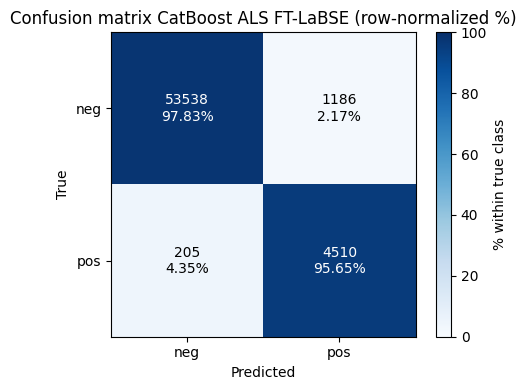

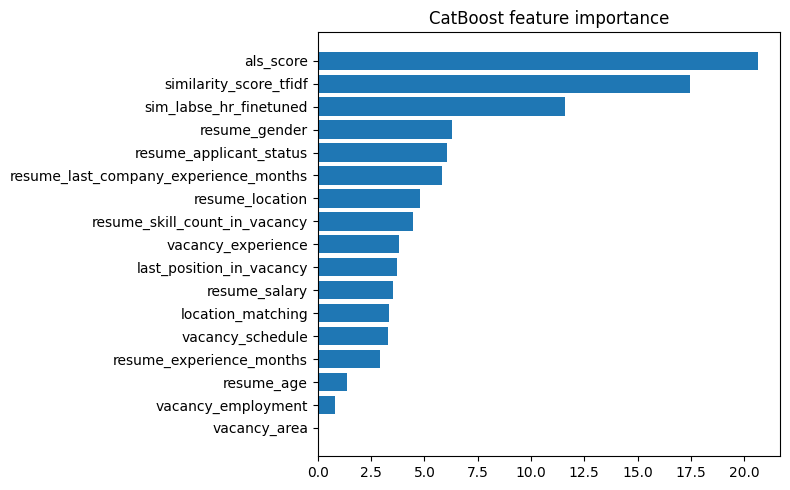

In [82]:
y_pred_bin = (proba_te >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_bin)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
for (i, j), v in np.ndenumerate(cm_pct):
    ax.text(j, i, f'{cm[i, j]}\n{v:.2f}%', ha='center', va='center',
            color='white' if v > 50 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['neg', 'pos']); ax.set_yticklabels(['neg', 'pos'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix CatBoost ALS FT-LaBSE (row-normalized %)')
fig.colorbar(im, label='% within true class')
cm_path = artifact_dir / 'confusion_matrix.png'
fig.tight_layout(); fig.savefig(cm_path, dpi=120); plt.show()

cb_clf = pipeline_cb_final.named_steps['model']
fi = cb_clf.feature_importances_
fi_names = final_features
order = np.argsort(fi)[::-1]
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.barh([fi_names[i] for i in order][::-1], [fi[i] for i in order][::-1])
ax2.set_title('CatBoost feature importance')
fi_path = artifact_dir / 'feature_importance.png'
fig2.tight_layout(); fig2.savefig(fi_path, dpi=120); plt.show()

sample_predictions = df_test_cb[['vacancy_id', 'resume_id', 'target', 'y_pred_proba']] \
    .sort_values('y_pred_proba', ascending=False).head(20)
sp_path = artifact_dir / 'predictions_sample.csv'
sample_predictions.to_csv(sp_path, index=False, encoding='utf-8')

In [68]:
mlflow.set_tracking_uri(f"http://{tracking_server_host}:{tracking_server_port}")
mlflow.set_registry_uri(f"http://{tracking_server_host}:{tracking_server_port}")

run_name_final = 'PRD'

signature_cb = mlflow.models.infer_signature(x_te, y_test)
input_example_cb = x_te[:10]

with mlflow.start_run(run_name=run_name_final,
                      experiment_id=final_experiment_id) as final_run:
    final_run_id = final_run.info.run_id

    mlflow.log_params(best_params_cb)
    mlflow.log_param('seed', random_state)
    mlflow.log_param('features', final_features)
    mlflow.log_param('finetune_epochs',
                     json.loads(state_file.read_text()).get('epochs_completed', 0))
    mlflow.log_param('finetune_pairs', len(ft_pairs))

    mlflow.log_metrics(metrics_final)

    mlflow.set_tags({
        'stage': 'PRD',
        'model_type': 'CatBoost+ALS+FineTuned-LaBSE',
        'finetune_base': finetune_base_model,
    })

    mlflow.log_artifact(str(cm_path),  artifact_path='plots')
    mlflow.log_artifact(str(fi_path),  artifact_path='plots')
    mlflow.log_artifact(str(sp_path),  artifact_path='predictions')

    model_info = mlflow.sklearn.log_model(
        sk_model=pipeline_cb_final,
        name='catboost_pipeline',
        registered_model_name=registered_model_name,
        signature=signature_cb,
        input_example=input_example_cb,
        await_registration_for=120,
    )

2026/05/31 22:25:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'hr-ai-scout-prd' already exists. Creating a new version of this model...
2026/05/31 22:25:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 120 seconds for model version to finish creation. Model name: hr-ai-scout-prd, version 3


🏃 View run PRD at: http://127.0.0.1:5000/#/experiments/2/runs/6e64aeb2c7ef499b9763a0369edda24c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


Created version '3' of model 'hr-ai-scout-prd'.


In [69]:
client = MlflowClient()
client.set_registered_model_alias(
    name=registered_model_name,
    alias=prd_alias,
    version=model_info.registered_model_version,
)

mv = client.get_model_version_by_alias(registered_model_name, prd_alias)
{'name': mv.name, 'alias': prd_alias, 'version': mv.version, 'run_id': mv.run_id}

{'name': 'hr-ai-scout-prd',
 'alias': 'PRD',
 'version': '3',
 'run_id': '6e64aeb2c7ef499b9763a0369edda24c'}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Локлаьный s3 и артефакты обучения - модель, графики, предсказания

- Сохраняем артефакты в локальный s3
- Перед запуском поднять MinIO командой docker run -d --name minio -p 9000:9000 -p 9001:9001 -e MINIO_ROOT_USER=minioadmin -e MINIO_ROOT_PASSWORD=minioadmin minio/minio server /data --console-address ":9001"
- S3 API на 127.0.0.1:9000, web UI на 127.0.0.1:9001 (логин minioadmin, пароль minioadmin)

</div>

In [ ]:
import boto3
import pickle
from botocore.client import Config

s3_endpoint   = "http://127.0.0.1:9000"
s3_access_key = "minioadmin"
s3_secret_key = "minioadmin"
s3_bucket     = "hr-ai-scout"

s3 = boto3.client(
    "s3",
    endpoint_url=s3_endpoint,
    aws_access_key_id=s3_access_key,
    aws_secret_access_key=s3_secret_key,
    config=Config(signature_version="s3v4"),
    region_name="us-east-1",
)

existing = [b["Name"] for b in s3.list_buckets().get("Buckets", [])]
if s3_bucket not in existing:
    s3.create_bucket(Bucket=s3_bucket)

run_prefix = f"runs/{final_run_id}"

s3.upload_file(str(cm_path),  s3_bucket, f"{run_prefix}/plots/confusion_matrix.png")
s3.upload_file(str(fi_path),  s3_bucket, f"{run_prefix}/plots/feature_importance.png")
s3.upload_file(str(sp_path),  s3_bucket, f"{run_prefix}/predictions/predictions_sample.csv")
s3.upload_file(str(bc_path),  s3_bucket, f"{run_prefix}/comparison/baseline_comparison.csv")
s3.upload_file(str(err_path), s3_bucket, f"{run_prefix}/errors/error_analysis.csv")
s3.upload_file(str(err_summary_path), s3_bucket, f"{run_prefix}/errors/error_summary.csv")

model_pkl = artifact_dir / "pipeline_cb_final.pkl"
with open(model_pkl, "wb") as f:
    pickle.dump(pipeline_cb_final, f)
s3.upload_file(str(model_pkl), s3_bucket, f"{run_prefix}/model/pipeline_cb_final.pkl")

objects = s3.list_objects_v2(Bucket=s3_bucket, Prefix=run_prefix).get("Contents", [])
pd.DataFrame([(o["Key"], o["Size"]) for o in objects], columns=["key", "size_bytes"])

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Сравнение бейзлайна и интерпретация разницы

- Сравниваем финальный CatBoost ALS FT LaBSE TF-IDF с бейзлайном по всем основным метрикам на одном и том же тестовом сете

</div>

In [70]:
baseline_comparison = pd.DataFrame([
    {
        'model':    'LogReg (TF-IDF)',
        'NDCG':     float(ndcg_lr),
        'Precision': float(precision_lr),
        'Recall':   float(recall_lr),
        'F1':       float(f1_lr),
    },
    {
        'model':    'CatBoost (ALS + FT-LaBSE + TF-IDF)  [PRD]',
        'NDCG':     float(ndcg_cb),
        'Precision': float(prec_cb),
        'Recall':   float(rec_cb),
        'F1':       float(f1_cb),
    },
])
baseline_comparison['NDCG_gain']  = baseline_comparison['NDCG']  - baseline_comparison.loc[0, 'NDCG']
baseline_comparison['F1_gain']    = baseline_comparison['F1']    - baseline_comparison.loc[0, 'F1']

bc_path = artifact_dir / 'baseline_comparison.csv'
baseline_comparison.to_csv(bc_path, index=False, encoding='utf-8')

client.log_artifact(final_run_id, str(bc_path), artifact_path='comparison')
client.log_metric(final_run_id, 'NDCG_gain_vs_baseline', float(ndcg_cb - ndcg_lr))
client.log_metric(final_run_id, 'F1_gain_vs_baseline',   float(f1_cb   - f1_lr))

baseline_comparison

,model,NDCG,Precision,Recall,F1,NDCG_gain,F1_gain
0,LogReg (TF-IDF),0.720924,0.606229,0.563855,0.568506,0.000000,0.00000
1,CatBoost (ALS + FT-LaBSE + TF-IDF) [PRD],0.749109,0.654576,0.729417,0.676376,0.028185,0.10787


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- Бейзлайн LogisticRegression на TF-IDF опирается только на поверхностное лексическое пересечение слов вакансии и резюме, без учета семантики и взаимодействий резюме с другими вакансиями
- Финальная модель CatBoost помимо TF-IDF использует ALS score, который ловит коллаборативный сигнал отклика рекрутера на похожих кандидатов, и LaBSE, которая понимает семантическое сходство даже при разных формулировках
- CatBoost нелинейно комбинирует категориальные и числовые фичи с этими тремя текстовыми сигналами, что дает прирост NDCG относительно линейного бейзлайна
- За счет ранжирования HR получает упорядоченный список соискателей, наиболее подходящие сверху

</div>

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Анализ ошибок

- Выделяем типичные ошибки модели на тестовом сете
- FP: модель выдала оценку выше 0.5, но таргет равен 0, рекрутер кандидата не взял
- FN: модель выдала оценку ниже, но таргет равен 1, кандидат подошел
- Для каждого класса берем топ 10 самых уверенных промахов

</div>

In [71]:
err_cols = [
    'vacancy_id', 'resume_id', 'target',
    'vacancy_area', 'vacancy_experience', 'vacancy_employment',
    'resume_location', 'resume_age', 'resume_experience_months',
    'resume_salary', 'resume_skill_count_in_vacancy',
    'last_position_in_vacancy', 'similarity_score_tfidf',
    'als_score',
]
err_df = df.loc[x_te.index, [c for c in err_cols if c in df.columns]].copy()
err_df['als_score']  = x_te['als_score'].values
err_df[ft_sim_col]   = x_te[ft_sim_col].values
err_df['y_pred_proba'] = proba_te
err_df['y_pred']     = y_pred_bin

fp_df = (err_df[(err_df['target'] == 0) & (err_df['y_pred'] == 1)]
         .sort_values('y_pred_proba', ascending=False).head(10))
fn_df = (err_df[(err_df['target'] == 1) & (err_df['y_pred'] == 0)]
         .sort_values('y_pred_proba', ascending=True).head(10))

errors_df = pd.concat([fp_df.assign(error_type='FP'),
                       fn_df.assign(error_type='FN')])
err_path = artifact_dir / 'error_analysis.csv'
errors_df.to_csv(err_path, index=False, encoding='utf-8')
client.log_artifact(final_run_id, str(err_path), artifact_path='errors')

errors_df.head(20)

,vacancy_id,resume_id,target,vacancy_area,vacancy_experience,vacancy_employment,resume_location,resume_age,resume_experience_months,resume_salary,resume_skill_count_in_vacancy,last_position_in_vacancy,similarity_score_tfidf,als_score,sim_labse_hr_finetuned,y_pred_proba,y_pred,error_type
140642,126399386,68435959,0,Москва,От 3 до 6 лет,Полная занятость,Москва,36.000000,202.0,400000.0,8,1.000000,0.191257,5.061110e-01,0.999805,0.999567,1,FP
215277,126470958,49599247,0,Москва,От 3 до 6 лет,Полная занятость,Москва,45.000000,151.0,0.0,7,0.000000,0.230541,1.705434e-01,0.999981,0.999398,1,FP
103892,125398321,48995041,0,Москва,От 3 до 6 лет,Полная занятость,Москва,36.000000,168.0,0.0,1,0.333333,0.306674,2.278507e-02,0.999829,0.999236,1,FP
178918,125605463,11612700,0,Москва,От 3 до 6 лет,Полная занятость,Санкт-Петербург,38.000000,173.0,0.0,6,0.400000,0.199191,1.539538e-01,0.999962,0.999217,1,FP
209728,126017127,69403682,0,Москва,От 1 года до 3 лет,Полная занятость,Москва,42.000000,274.0,0.0,1,0.000000,0.327946,7.886748e-02,0.999806,0.999019,1,FP
55868,125401685,144512800,0,Москва,От 3 до 6 лет,Полная занятость,Ташкент,44.060813,259.0,0.0,2,0.000000,0.250412,1.174218e-01,0.999957,0.998945,1,FP
53272,126158474,26594672,0,Москва,От 1 года до 3 лет,Полная занятость,Москва,37.000000,187.0,100000.0,0,0.500000,0.219603,6.594580e-02,0.999467,0.998864,1,FP
232102,125543257,45097811,0,Москва,От 3 до 6 лет,Полная занятость,Москва,33.000000,83.0,117000.0,4,0.500000,0.220308,2.216445e-02,0.999356,0.998790,1,FP
111067,125836219,151173414,0,Москва,От 3 до 6 лет,Полная занятость,Актау,25.000000,14.0,0.0,1,0.000000,0.237889,1.473781e-01,0.999945,0.998728,1,FP
201062,125435818,147310971,0,Москва,От 3 до 6 лет,Полная занятость,Москва,44.060813,57.0,450000.0,7,0.000000,0.240446,5.335237e-02,0.999983,0.998634,1,FP


In [72]:
err_summary = (
    errors_df.groupby('error_type')
    .agg(
        n=('target', 'size'),
        mean_proba=('y_pred_proba', 'mean'),
        mean_als=('als_score', 'mean'),
        mean_ft_labse=(ft_sim_col, 'mean'),
        mean_tfidf=('similarity_score_tfidf', 'mean'),
        mean_skill=('resume_skill_count_in_vacancy', 'mean'),
        mean_last_pos=('last_position_in_vacancy', 'mean'),
        mean_age=('resume_age', 'mean'),
        mean_exp=('resume_experience_months', 'mean'),
    )
    .round(3)
)

err_summary_path = artifact_dir / 'error_summary.csv'
err_summary.to_csv(err_summary_path)
client.log_artifact(final_run_id, str(err_summary_path), artifact_path='errors')

err_summary

,n,mean_proba,mean_als,mean_ft_labse,mean_tfidf,mean_skill,mean_last_pos,mean_age,mean_exp
error_type,,,,,,,,,
FN,10,0.001,-0.001,0.447,0.028,0.3,0.070,51.800,265.1
FP,10,0.999,0.134,1.000,0.242,3.7,0.273,38.012,156.8


<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

Robustness: оцениваем как изменение в данных влияет на предсказания

- Проверка на "читинг"
- Берем случайную подвыборку из тестового сета и модифицируем разными способами
- Дублирование описания вакансии в опыт кандидата много раз, как самый очевидный способ накрутить фичи
- Просто вставка описания вакансии в опыт кандидата один раз
- Замена опыта на случайный текст того же кандидата, чтобы оценить шум
- Для каждой модификации пересчитываем метрики, смотрим на результат

</div>

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

На Confusion матрице можно заметить, что доля FP / FN меньше 5%, что считаю хорошими результатами

Ошибки и причины и и можно ли их скорректировать


- FP - при высоких метриках, а по факту "рекрутер" все равно отказал - "рекрутер" видит детали грейд бэкграунд компании которых нет в фичах, нельзя без расширения признакового пространства, (по факту это была LLM так что просто сыграло наше ограничение на кол-во сосикателей на каждую позицию)
- FP - overconfident ALS, высокий als score, кандидат уже откликался на похожие вакансии, ALS помнит популярных кандидатов, но они не подходят под конкретную вакансию
- FN пустое поле, нулевой или низкий als score, пустой last position in vacancy, короткое resume last experience description, у кандидата мало текстовой информации и модель не может построить устойчивое предсказание, нельзя на этих данных нужны более богатые резюме
- FN - гео несоответствие, location matching равен 0, но рекрутер все равно взял релокация или удаленка, модель штрафует за несовпадение локации, рекрутер нет, можно отдельно обрабатывать vacancy schedule
- FN - нетипичная должность, низкая схожесть, но "рекрутер" увидел смежные навыки, TF-IDF и LaBSE плохо схватывают переход между разными ролями например аналитик в ML-инженер

</div>

In [73]:
rng = np.random.RandomState(random_state)
n_sample = min(200, len(x_te))
sample_pos = rng.choice(len(x_te), size=n_sample, replace=False)

sample_index   = x_te.index[sample_pos]
df_sample      = df.loc[sample_index, [
    'vacancy_id', 'resume_id',
    'vacancy_description', 'resume_last_experience_description',
    'resume_last_position', 'resume_skills',
]].copy()

x_robust_base = x_te.iloc[sample_pos].copy()
proba_base = pipeline_cb_final.predict_proba(x_robust_base)[:, 1]

_tok_rob = AutoTokenizer.from_pretrained(str(finetune_save_path))
_mdl_rob = AutoModel.from_pretrained(str(finetune_save_path)).to(device).eval()


def _ft_sim_for_texts(vacancy_texts, resume_texts):
    vac_emb = encode_texts(list(vacancy_texts), _tok_rob, _mdl_rob, batch_size=64)
    res_emb = encode_texts(list(resume_texts),  _tok_rob, _mdl_rob, batch_size=64)
    return (vac_emb * res_emb).sum(axis=1).astype(np.float32)


def _apply_modification(df_part):
    x_mod = x_robust_base.copy()
    x_mod[ft_sim_col] = _ft_sim_for_texts(
        df_part['vacancy_description'].fillna('').astype(str).tolist(),
        df_part['resume_last_experience_description'].fillna('').astype(str).tolist(),
    )
    x_mod['resume_skill_count_in_vacancy'] = df_part.apply(
        resume_skill_count_in_vacancy, axis=1).values
    x_mod['last_position_in_vacancy'] = df_part.apply(
        last_position_in_vacancy, axis=1).values
    return x_mod


robustness_results = {}

df_mod1 = df_sample.copy()
df_mod1['resume_last_experience_description'] = (
    df_mod1['vacancy_description'].fillna('').astype(str) * 10)
x_p1 = _apply_modification(df_mod1)
proba_p1 = pipeline_cb_final.predict_proba(x_p1)[:, 1]
robustness_results['duplicate_vacancy_x10_into_experience'] = float(
    np.mean(np.abs(proba_p1 - proba_base)))

df_mod2 = df_sample.copy()
df_mod2['resume_last_experience_description'] = (
    df_mod2['resume_last_experience_description'].fillna('').astype(str)
    + ' '
    + df_mod2['vacancy_description'].fillna('').astype(str)
)
x_p2 = _apply_modification(df_mod2)
proba_p2 = pipeline_cb_final.predict_proba(x_p2)[:, 1]
robustness_results['append_vacancy_to_experience_x1'] = float(
    np.mean(np.abs(proba_p2 - proba_base)))

df_mod3 = df_sample.copy()
shuffled_exp = df_sample['resume_last_experience_description'].sample(
    frac=1, random_state=random_state).values
df_mod3['resume_last_experience_description'] = shuffled_exp
x_p3 = _apply_modification(df_mod3)
proba_p3 = pipeline_cb_final.predict_proba(x_p3)[:, 1]
robustness_results['shuffle_experience_random'] = float(
    np.mean(np.abs(proba_p3 - proba_base)))

del _tok_rob, _mdl_rob
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()

for k, v in robustness_results.items():
    client.log_metric(final_run_id, f'robustness_{k}', v)

robustness_results

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

encoding:   0%|          | 0/4 [00:00<?, ?it/s]

{'duplicate_vacancy_x10_into_experience': 0.025788355497988705,
 'append_vacancy_to_experience_x1': 0.026607352659087997,
 'shuffle_experience_random': 0.028568702525769877}

<div style="background-color: #98FB98; color: black; padding: 10px; border-radius: 5px;">

- MAE на оценке около 2,6%, значит, что модель почти не меняет уверенность при атаках на текст
- Смена класса только у 2-3%, что совсем не критично. Задача отобрать и ранжировать
- Копипаст вакансии в опыт кандидата не работает как читинг
- Случайный чужой опыт дает такую же реакцию как и осмысленная атака, модель опирается не на текст, а на числовые признаки и ALS
- Поведение устойчивое, текстовый канал не доминирует

</div>

In [ ]:
vacancy_id = 126372900

pd.set_option('display.max_colwidth', 500)

cols = [
    'vacancy_id', 'resume_id', 'target',
    'resume_last_position', 'resume_location', 'resume_gender',
    'resume_age', 'resume_experience_months', 'resume_salary',
    'resume_skills', 'resume_last_experience_description',
]
df_positives = df[(df['vacancy_id'] == vacancy_id) & (df['target'] == 1)][cols].reset_index(drop=True)
df_positives

,vacancy_id,resume_id,target,resume_last_position,resume_location,resume_gender,resume_age,resume_experience_months,resume_salary,resume_skills,resume_last_experience_description
0,126372900,81536760,1,"Project manager, Интернет-маркетолог, SEO-специалист, SMM-менеджер, Таргетолог, Контекстная реклама",Новосибирск,Мужчина,38.0,238.0,0.0,"['Контекстная реклама', 'Ведение групп в социальных сетях', 'Яндекс.Директ', 'Яндекс.Метрика', 'Google Analytics', 'CMS Wordpress', 'HTML', '1С-Битрикс', 'Google AdWords', 'E-Mail Marketing', 'Adobe Photoshop', 'Joomla CMS', 'Интернет-реклама', 'CRM', 'Управление интернет-проектами', 'Интернет маркетинг', 'ABC-анализ', 'Маркетинг услуг', 'Копирайтинг', 'SMM', 'B2C продажи', 'Анализ продаж', 'Аналитическое мышление', 'Статистический анализ', 'Маркетинг', 'Email маркетинг', 'SEO оптимизация', ...","Если вас заинтересует мое резюме, пожалуйста, отправляйте приглашение на вакансию.\n\nКейсы описаны в конце резюме.\n\n------------------------------\n\nОПЫТ И НАВЫКИ\n\nУправление командой отдела маркетинга и разработки (маркетологи, директологи, таргетологи, smm-менеджеры, контент-менеджеры, копирайтеры, фотографы, видеооператоры, монтажеры, дизайнеры, fullstack- frontend- backend-разработчики).\n\nAgile, scrum, kanban, waterfall или смешанная модель в зависимости от задачи/проекта. Постан..."
1,126372900,127146719,1,Интернет-маркетолог,Москва,Мужчина,30.0,77.0,70000.0,"['Обучаемость', 'Английский язык', 'Пользователь ПК', 'Поиск информации в интернет', 'Развитие продаж', 'SMM', 'Контекстная реклама', 'Формирование технического задания для разработки', 'Google AdWords', 'CRM', 'Разработка маркетинговой стратегии', 'Управление интернет-проектами', 'Яндекс.Директ', 'Реклама', 'Продвижение бренда', 'Креативность', 'Интернет маркетинг']","-Составление и согласование технического задания.\n-Разработка и согласование прототипа.\n-Планирование плана проекта и разработки, разбивка на задачи и подзадачи, назначение исполнителей.\n-Контроль сроков и качество выполнения задач.\n-Обработка входящих задач от клиентов с последующим распределением внутри команды.\n-Техническая поддержка текущих клиентов\n-Общение с клиентами, генерациях новых идеи и решений для внедрениях в их бизнес.\n-Развитие собственного продукта\n-Управлением конте..."
2,126372900,138154924,1,Product owner,Москва,Мужчина,39.0,174.0,300000.0,"['Холодные продажи', 'B2B Продажи', 'Проведение презентаций', 'Развитие продаж', 'CRM', 'Холодные звонки', 'Развитие ключевых клиентов', 'Руководство коллективом', 'Подготовка коммерческих предложений', 'Навыки переговоров', 'Анализ конкурентной среды', 'Управление командой', 'Запуск новых продуктов', 'Мобильность', 'Мотивация', 'проведение переговоров с первыми лицами компании', 'Time management', 'Agile Project Management', 'Управление продуктом', 'Разработка нового продукта', 'Анализ рынк...","Была проектная работа сроком на 1,5 года\nЗадача стояла следующая:\nСоздание и внедрение МИС(медицинская информационная система) для клиники и врача частника. Так как клиника работает по своей уникальной схеме лечения пациентов в узкой нише «Anti age медицина», то стандартные МИС ей не подходили по ряду причин. Было принято решение разработать свою собственную МИС. Провели продуктовую проработку, описали все этапы взаимодействия с пациентом от записи на прием до контроля процесса лечения и п..."
3,126372900,141504612,1,Product Owner/Project Manager/CEO,Москва,Мужчина,36.0,142.0,0.0,"['Управление проектами', 'Управление командой', 'Product Management', 'Бизнес-анализ', 'Product Marketing', 'Presentation skills', 'Управление рисками', 'Time management', 'Start-up project', 'Обучение и развитие', 'Аналитическое мышление', 'MS Project', 'Управление бизнес процессами', 'Business Development', 'Ресурсное планирование', 'Бюджетное планирование', 'Выстраивание процессов', 'Управление компанией', 'Пресейл', 'Waterfall', 'Agile', 'Scrum', 'Лидерство', 'Управление требованиями', '...","Создал продуктовый бизнес, совмещенный